Kasus ini menggunakan logika fuzzy untuk membantu pelanggan menentukan persentase tip yang direkomendasikan berdasarkan penilaian terhadap pelayanan dan rasa makanan pada sebuah restoran.

### 1. Variabel Input (Antecedent)
Terdapat dua faktor utama yang menjadi metrik penilaian pelanggan:
* **Rasa Makanan**
  * **Semesta Pembicaraan (*Universe*):** Seberapa enak rasa makanan dalam skala 0 sampai 10.
  * **Himpunan Fuzzy (*Fuzzy Set*):** Dibagi menjadi tiga kategori, yaitu `tidak enak`, `biasa`, dan `enak`.
* **Pelayanan**
  * **Semesta Pembicaraan (*Universe*):** Seberapa baik pelayanan restoran dalam skala 0 sampai 10.
  * **Himpunan Fuzzy (*Fuzzy Set*):** Dibagi menjadi tiga kategori, yaitu `buruk`, `biasa`, dan `baik`.

### 2. Variabel Output (Consequent)
* **Tip**
  * **Semesta Pembicaraan (*Universe*):** Persentase tip yang harus dikeluarkan dari skala 0% sampai 25%.
  * **Himpunan Fuzzy (*Fuzzy Set*):** Dibagi menjadi tiga kategori, yaitu `sedikit`, `sedang`, dan `banyak`.

### 3. Dasar Aturan (Rule Base)
Sistem ini dieksekusi menggunakan 5 aturan logika fuzzy (IF-THEN) berikut:
1. **JIKA** rasa TIDAK ENAK **ATAU** pelayanan BURUK, **MAKA** tip SEDIKIT.
2. **JIKA** rasa BIASA **DAN** pelayanan BIASA, **MAKA** tip SEDANG.
3. **JIKA** rasa ENAK **DAN** pelayanan BIASA, **MAKA** tip SEDANG.
4. **JIKA** rasa BIASA **DAN** pelayanan BAIK, **MAKA** tip BANYAK.
5. **JIKA** rasa ENAK **DAN** pelayanan BAIK, **MAKA** tip BANYAK.


In [3]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl



In [4]:
rasa = ctrl.Antecedent(np.arange(0,11,1), 'rasa')
pelayanan = ctrl.Antecedent(np.arange(0,11,1), 'pelayanan')
tip = ctrl.Consequent(np.arange(0,26,1), 'tip')

c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


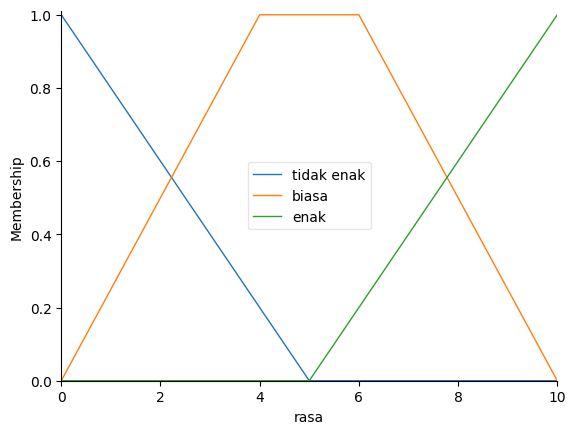

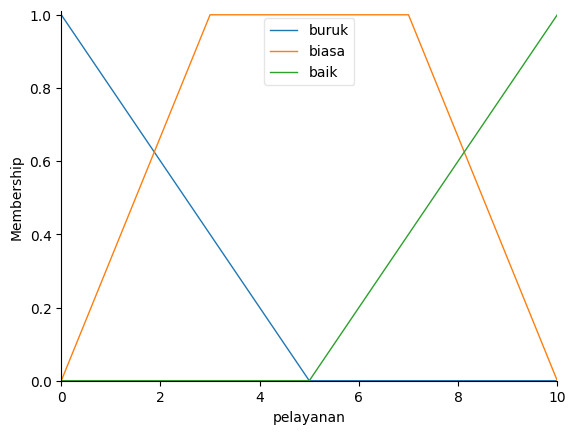

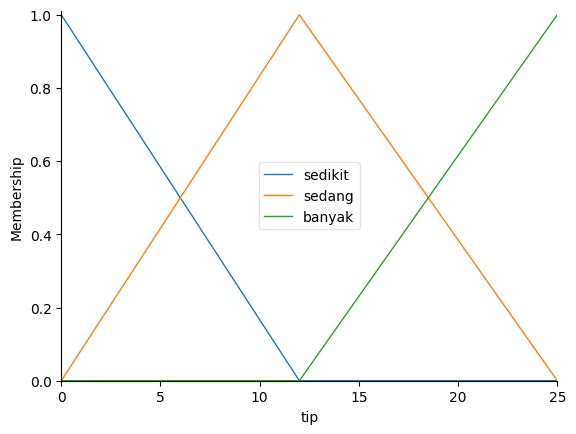

In [10]:
rasa['tidak enak'] = fuzz.trimf(rasa.universe,[0,0,5])
rasa['biasa'] = fuzz.trapmf(rasa.universe, [0,4,6,10])
rasa['enak'] = fuzz.trimf(rasa.universe, [5,10,10])

pelayanan['buruk'] = fuzz.trimf(pelayanan.universe,[0,0,5])
pelayanan['biasa'] = fuzz.trapmf(pelayanan.universe, [0,3,7,10])
pelayanan['baik'] = fuzz.trimf(pelayanan.universe, [5,10,10])

tip['sedikit'] = fuzz.trimf(tip.universe,[0,0,12])
tip['sedang'] = fuzz.trimf(tip.universe, [0,12,25])
tip['banyak'] = fuzz.trimf(tip.universe, [12,25,25])

rasa.view()
pelayanan.view()
tip.view()

In [15]:
rules = [
    ctrl.Rule(rasa['tidak enak'] | pelayanan['buruk'], tip['sedikit']),
    ctrl.Rule(rasa['biasa'] | pelayanan['biasa'], tip['sedang']),
    ctrl.Rule(rasa['enak'] | pelayanan['biasa'], tip['sedang']),
    ctrl.Rule(rasa['biasa'] | pelayanan['baik'], tip['banyak']),
    ctrl.Rule(rasa['enak'] | pelayanan['baik'], tip['banyak']),
]

tipping_ctrl = ctrl.ControlSystem(rules)
tipping_sim = ctrl.ControlSystemSimulation(tipping_ctrl)
print(tipping_ctrl)
print(tipping_sim)

In [18]:
tipping_sim.input["rasa"] = 7.5
tipping_sim.input["pelayanan"] = 8.0

tipping_sim.compute()

hasil_tip_dari_fuzzy = tipping_sim.output['tip']

print(f"""Tip untuk restoran A berdasarkan sistem fuzzy tersebut adalah {hasil_tip_dari_fuzzy:.2f}%""")

Tip untuk restoran A berdasarkan sistem fuzzy tersebut adalah 14.15%
